In [1]:
print("Hello, World!")

Hello, World!


Question 01

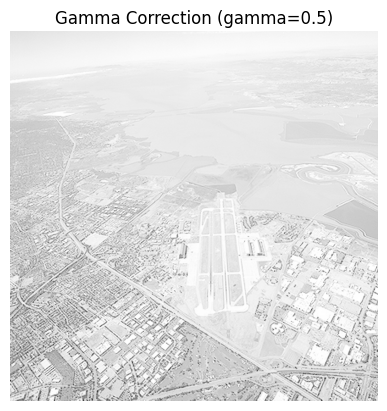

In [1]:
#part a)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img = cv.imread('runway.png')
assert img is not None, "Image not found"
gamma = 0.5
t = np.array(255 * (img / 255) ** gamma, dtype='uint8')
plt.imshow(t)
plt.title('Gamma Correction (gamma=0.5)')
plt.axis('off')
plt.show()


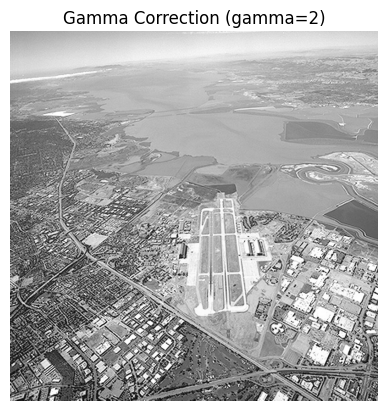

In [2]:
#part b)
gamma = 2
t = np.array(255 * (img / 255) ** gamma, dtype='uint8')
plt.imshow(t)
plt.title('Gamma Correction (gamma=2)')
plt.axis('off')
plt.show()

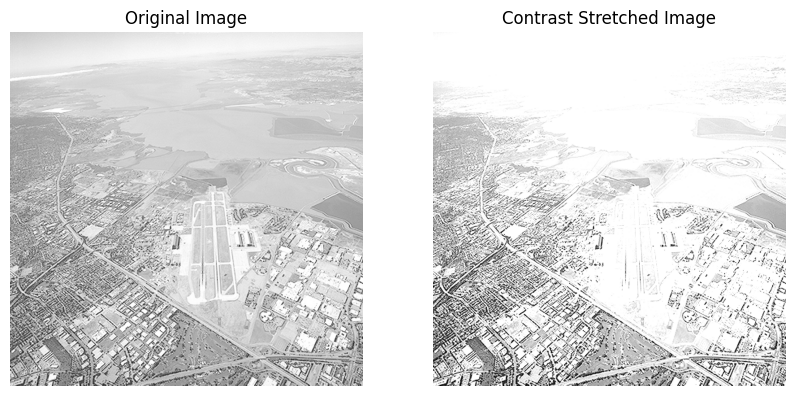

In [3]:
#part c)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
img = cv2.imread('runway.png', 0)

# Normalize to [0,1]
r = img / 255.0

# Define r1 and r2
r1 = 0.2
r2 = 0.8

# Apply piecewise transformation
s = np.zeros_like(r)

s[r < r1] = 0
s[r > r2] = 1
mask = (r >= r1) & (r <= r2)
s[mask] = (r[mask] - r1) / (r2 - r1)

# Convert back to [0,255]
output = (s * 255).astype(np.uint8)

# Display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title('Contrast Stretched Image')
plt.axis('off')

plt.show()  


Question 02

In [7]:
# part a)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
 
# Read image (BGR)
img = cv.imread('highlights_and_shadows.jpg')

# Convert to LAB color space
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

# Split channels
L, A, B = cv.split(lab)

# Normalize L channel to [0,1]
L_norm = L / 255.0

# Apply gamma correction
gamma = 0.5
L_gamma = np.power(L_norm, gamma)

# Convert back to [0,255]
L_new = np.uint8(L_gamma * 255)

# Merge channels
lab_corrected = cv.merge((L_new, A, B))

# Convert back to BGR
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

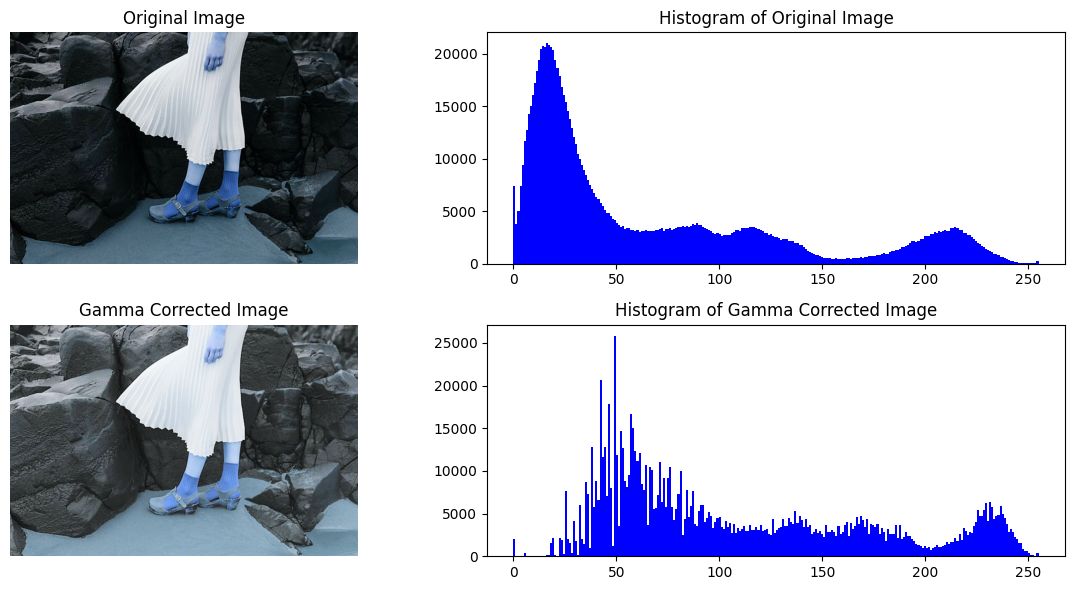

In [10]:
#part b)
  
#Adding the histogram of the original and corrected images
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.subplot(2,2,2)
plt.hist(img.ravel(), bins=256, range=(0,255), color='blue')
plt.title('Histogram of Original Image')
plt.subplot(2,2,3)
plt.imshow(img_corrected)
plt.title('Gamma Corrected Image')
plt.axis('off')
plt.subplot(2,2,4)
plt.hist(img_corrected.ravel(), bins=256, range=(0,255), color='blue')
plt.title('Histogram of Gamma Corrected Image')
plt.tight_layout()
plt.show()